In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
dataset = pd.read_csv('data/salary.csv')

In [61]:
dataset.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [62]:
dataset["Gender"].isnull().sum()

np.int64(2)

In [63]:
gens = {"Male":1, "Female":2, "Other":0}
dataset["Gender"] = dataset["Gender"].map(gens)

In [64]:
dataset["Gender"].value_counts()

Gender
1.0    3674
2.0    3014
0.0      14
Name: count, dtype: int64

In [65]:
dataset["Gender"] = dataset["Gender"].fillna(dataset["Gender"].mode()[0])

In [66]:
dataset["Gender"].isnull().sum()

np.int64(0)

In [67]:
dataset["Gender"].head()

0    1.0
1    2.0
2    1.0
3    2.0
4    1.0
Name: Gender, dtype: float64

In [68]:
dataset["Education Level"].value_counts()

Education Level
Bachelor's Degree    2267
Master's Degree      1573
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64

In [69]:
dataset["Education Level"].isnull().sum()

np.int64(3)

In [70]:
edu = {"Bachelor's Degree":1, "Master's Degree":2, "PhD":3, "Bachelor's":1, "High School":0, "Master's":2, "phD":3}
dataset["Education Level"] = dataset["Education Level"].map(edu)

In [71]:
dataset["Education Level"] = dataset["Education Level"].fillna(dataset["Education Level"].mode()[0])

In [72]:
dataset["Education Level"].head()

0    1.0
1    2.0
2    3.0
3    1.0
4    2.0
Name: Education Level, dtype: float64

In [73]:
dataset["Education Level"].isnull().sum()

np.int64(0)

In [74]:
dataset["Job Title"].unique()

<ArrowStringArray>
[           'Software Engineer',                 'Data Analyst',
               'Senior Manager',              'Sales Associate',
                     'Director',            'Marketing Analyst',
              'Product Manager',                'Sales Manager',
        'Marketing Coordinator',             'Senior Scientist',
 ...
       'Junior Sales Associate',      'Human Resources Manager',
        'Juniour HR Generalist',       'Juniour HR Coordinator',
 'Digital Marketing Specialist',                 'Receptionist',
           'Marketing Director',                     'Social M',
             'Social Media Man',              'Delivery Driver']
Length: 194, dtype: str

In [75]:
from sklearn.preprocessing import LabelEncoder

In [76]:
le = LabelEncoder()
dataset["Job Title"] = le.fit_transform(dataset["Job Title"])

In [77]:
dataset["Job Title"].isnull().sum()

np.int64(0)

In [92]:
dataset["Salary"].isnull().sum()

np.int64(5)

In [93]:
dataset["Salary"] = dataset["Salary"].fillna(dataset["Salary"].mean())

In [94]:
dataset["Salary"].isnull().sum()

np.int64(0)

In [78]:
dataset.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1.0,1.0,177,5.0,90000.0
1,28.0,2.0,2.0,18,3.0,65000.0
2,45.0,1.0,3.0,145,15.0,150000.0
3,36.0,2.0,1.0,116,7.0,60000.0
4,52.0,1.0,2.0,26,20.0,200000.0


In [79]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6704 non-null   float64
 2   Education Level      6704 non-null   float64
 3   Job Title            6704 non-null   int64  
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 314.4 KB


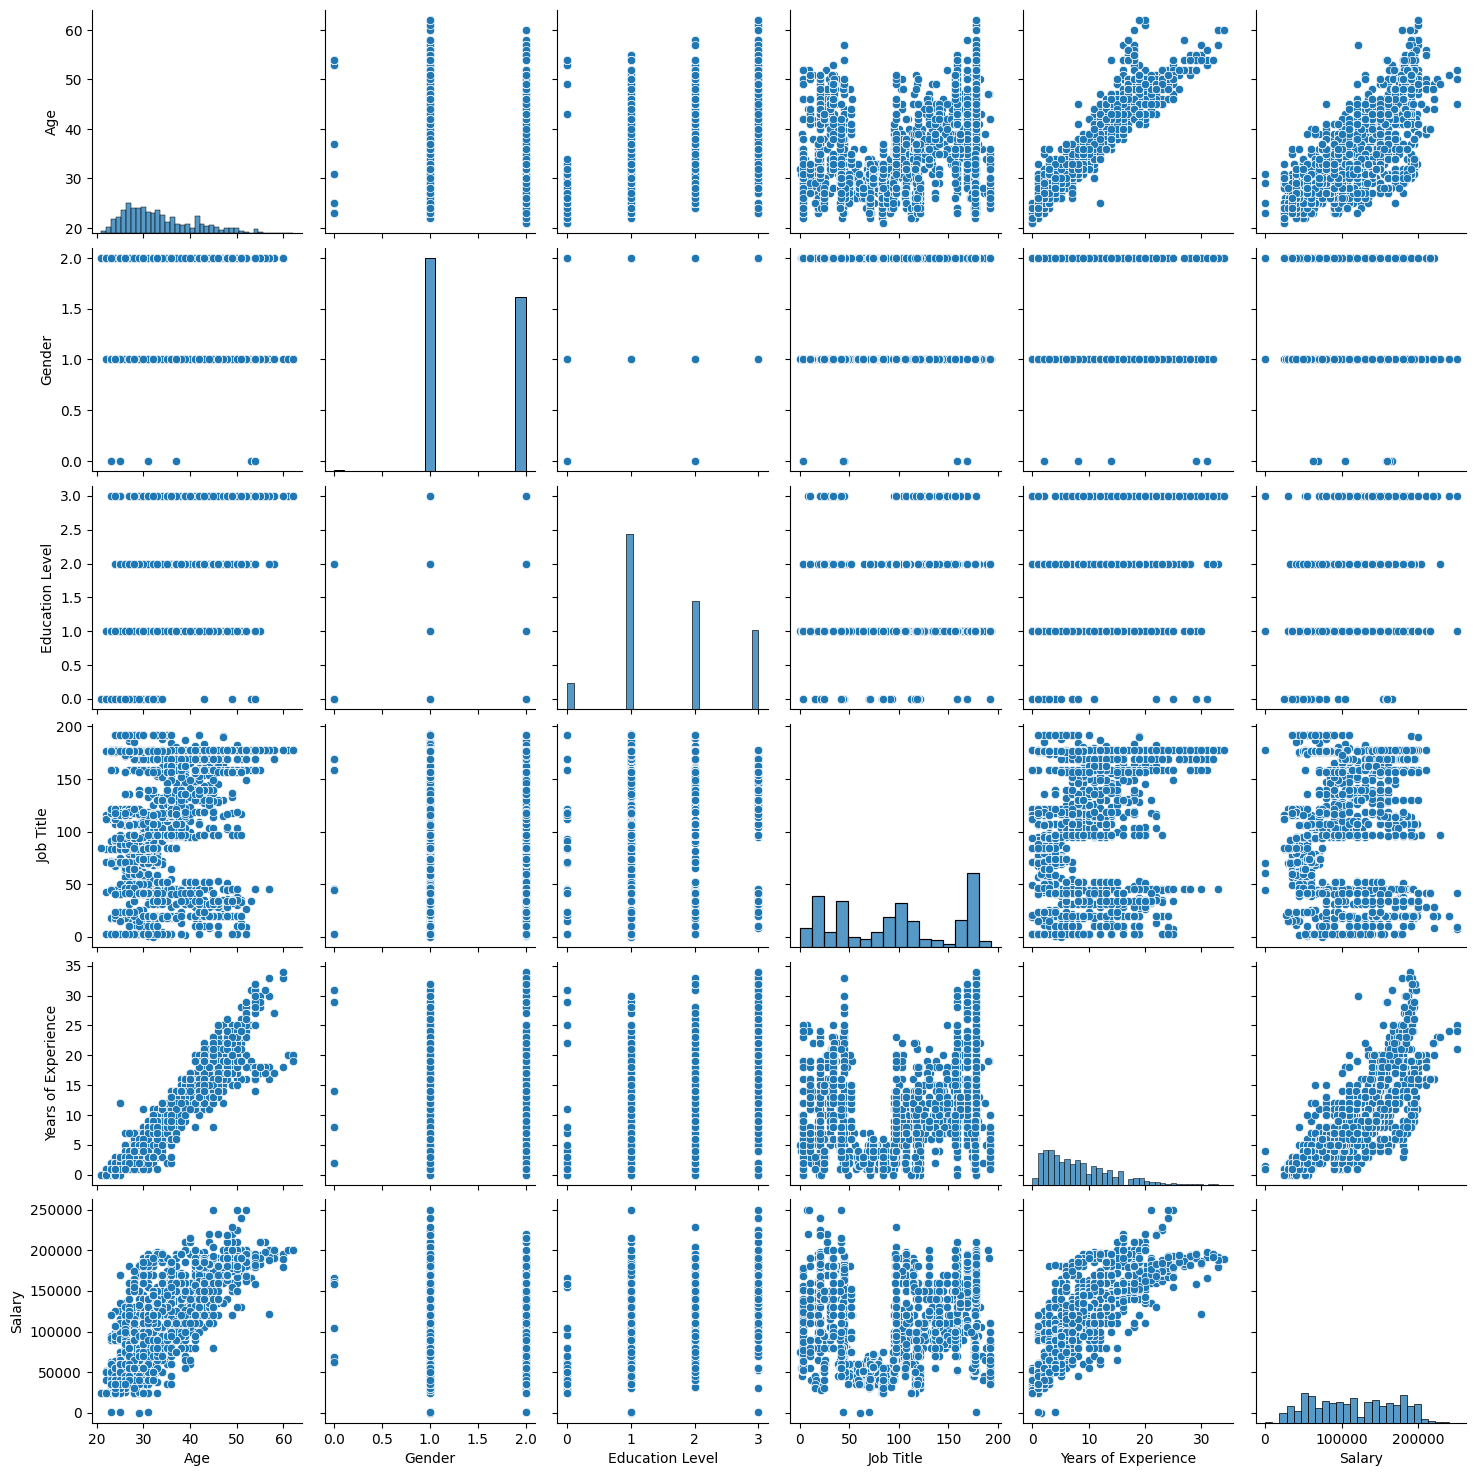

In [82]:
sns.pairplot(data = dataset)
plt.show()

In [95]:
x = dataset.iloc[:,:-1]
y = dataset["Salary"]

In [96]:
from sklearn.model_selection import train_test_split

In [98]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [99]:
from sklearn.tree import DecisionTreeRegressor

In [106]:
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [107]:
dt.score(x_test, y_test), dt.score(x_train, y_train)

(0.9527801783724892, 0.9942078620539502)

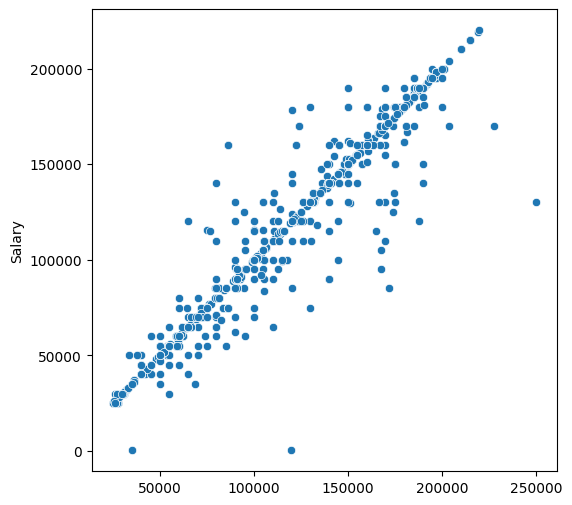

In [118]:
plt.figure(figsize=(6,6))
sns.scatterplot(y = y_test, x=dt.predict(x_test))
plt.show()

In [123]:
depth = dt.get_depth()
depth

20

In [124]:
for i in range(1, 21):
    dt2 = DecisionTreeRegressor(max_depth=i)
    dt2.fit(x_train, y_train)
    print(f"{i}. Training score: {dt2.score(x_train, y_train)}, Test score: {dt2.score(x_test, y_test)}")

1. Training score: 0.5531132928043134, Test score: 0.5464990460943233
2. Training score: 0.6911368456020823, Test score: 0.6954946811064076
3. Training score: 0.7528568364469153, Test score: 0.7536961106747311
4. Training score: 0.8140560906204966, Test score: 0.8024091553012804
5. Training score: 0.85936078580068, Test score: 0.8437625316932852
6. Training score: 0.8982679319635506, Test score: 0.8787602918506175
7. Training score: 0.930016996353913, Test score: 0.9071819480429937
8. Training score: 0.9524147531198516, Test score: 0.9277622772151506
9. Training score: 0.9670721814179979, Test score: 0.9367212960538123
10. Training score: 0.9798489336738239, Test score: 0.9481214061722248
11. Training score: 0.9858992221086235, Test score: 0.9498289987924043
12. Training score: 0.9896488029716737, Test score: 0.9499227323669052
13. Training score: 0.9924518233495372, Test score: 0.954249106864421
14. Training score: 0.9934585720759558, Test score: 0.9543393961302739
15. Training score:

In [125]:
best_depth = 19

dt = DecisionTreeRegressor(max_depth = 19)
dt.fit(x_train, y_train)
dt.score(x_test, y_test), dt.score(x_train, y_train)

(0.9565225101428011, 0.9942053267768106)